<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/Proyecto%3A%20Prep%C3%A1rate%20para%20el%20mercado%20laboral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías importadas correctamente
Dataset generado: 500 filas, 9 columnas

Primeras 5 filas:
   customer_id  edad  ingreso_anual  gasto_total  frecuencia_compras  \
0            1    56          92443         2024                  10   
1            2    69          70649         4054                   8   
2            3    46          19613         2051                  10   
3            4    32          40315         5632                  10   
4            5    60          75338         3493                   7   

   ticket_promedio  antiguedad_meses  dias_desde_ultima_compra  \
0            58.37               8.6                 57.028726   
1            78.03              19.9                  6.751676   
2            63.01              39.1                 81.740500   
3            19.94               3.5                 35.047328   
4            71.04              20.9                 51.994509   

   puntos_fidelidad  
0               511  
1               542  
2         

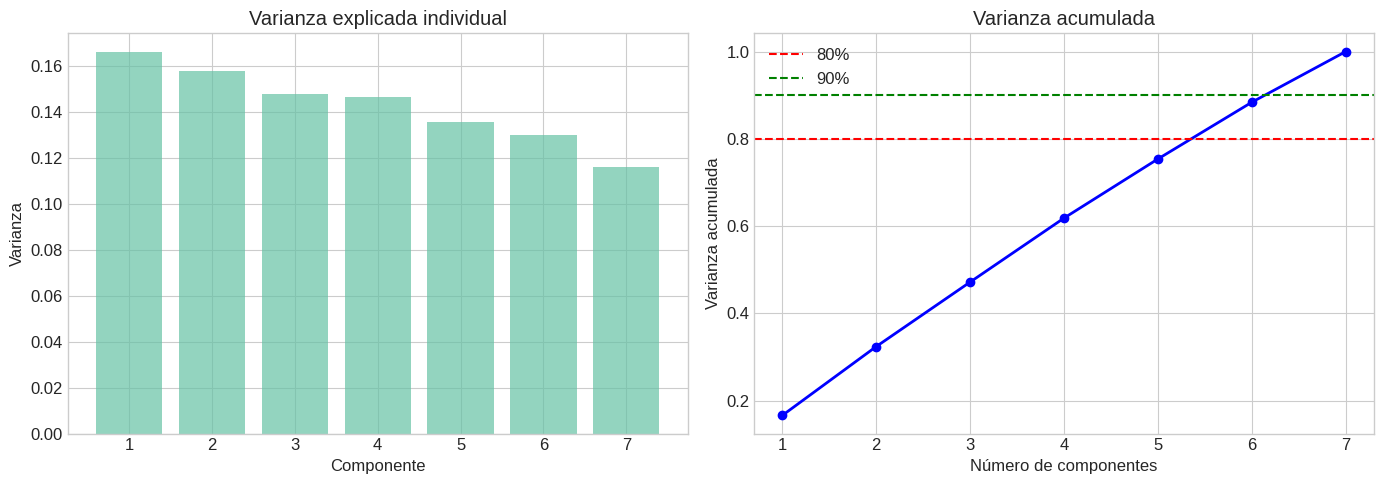


Calculando t-SNE (puede tomar unos segundos)...
t-SNE completado.


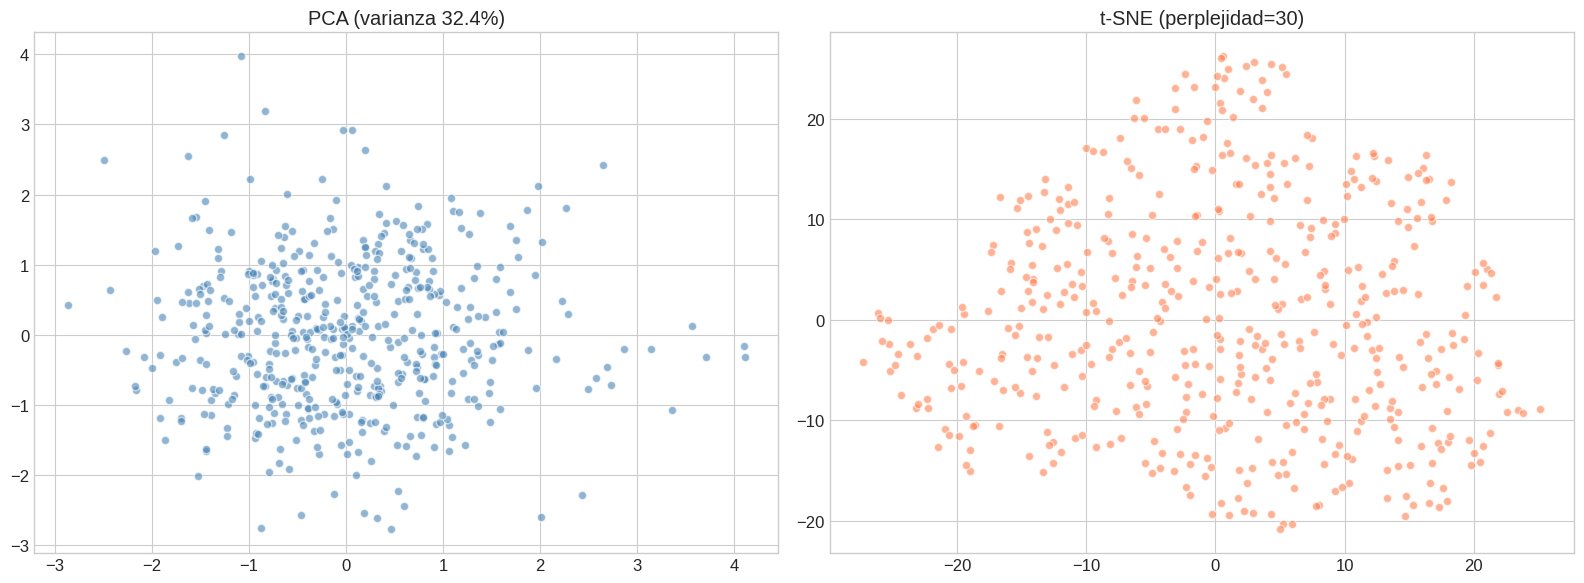

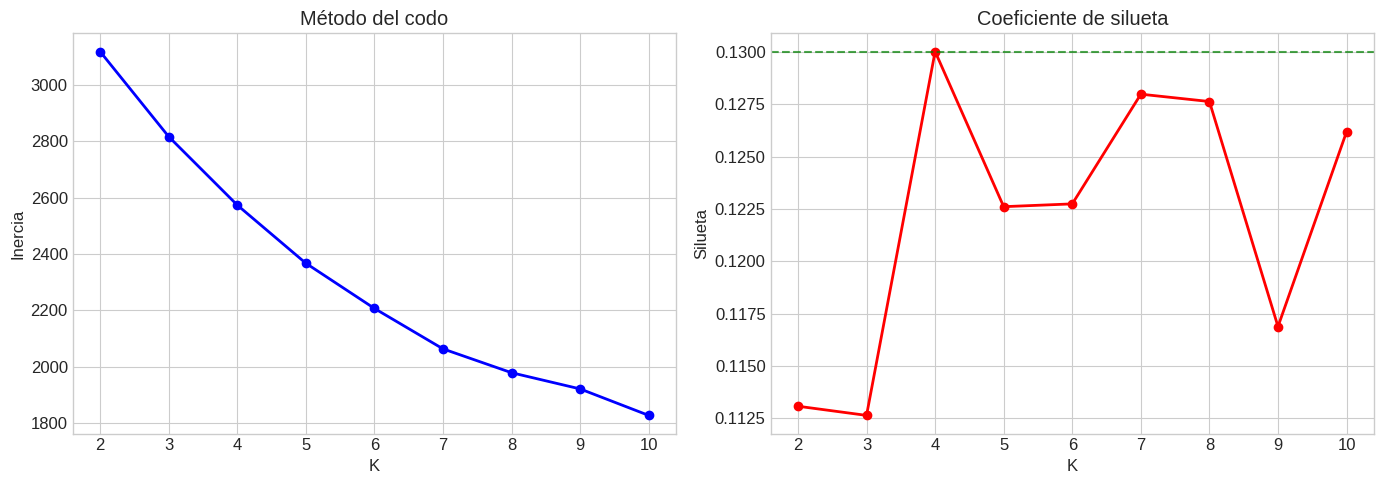


Mejor K según silueta: 4 (silueta=0.1300)
eps=1.0: clusters=8, ruido=456, silueta=0.2988

--- Resultados de clustering ---
K-Means (K=4): silueta=0.1300
DBSCAN (eps=1.0): silueta=0.2988, ruido=456
Jerárquico (K=4): silueta=0.0619


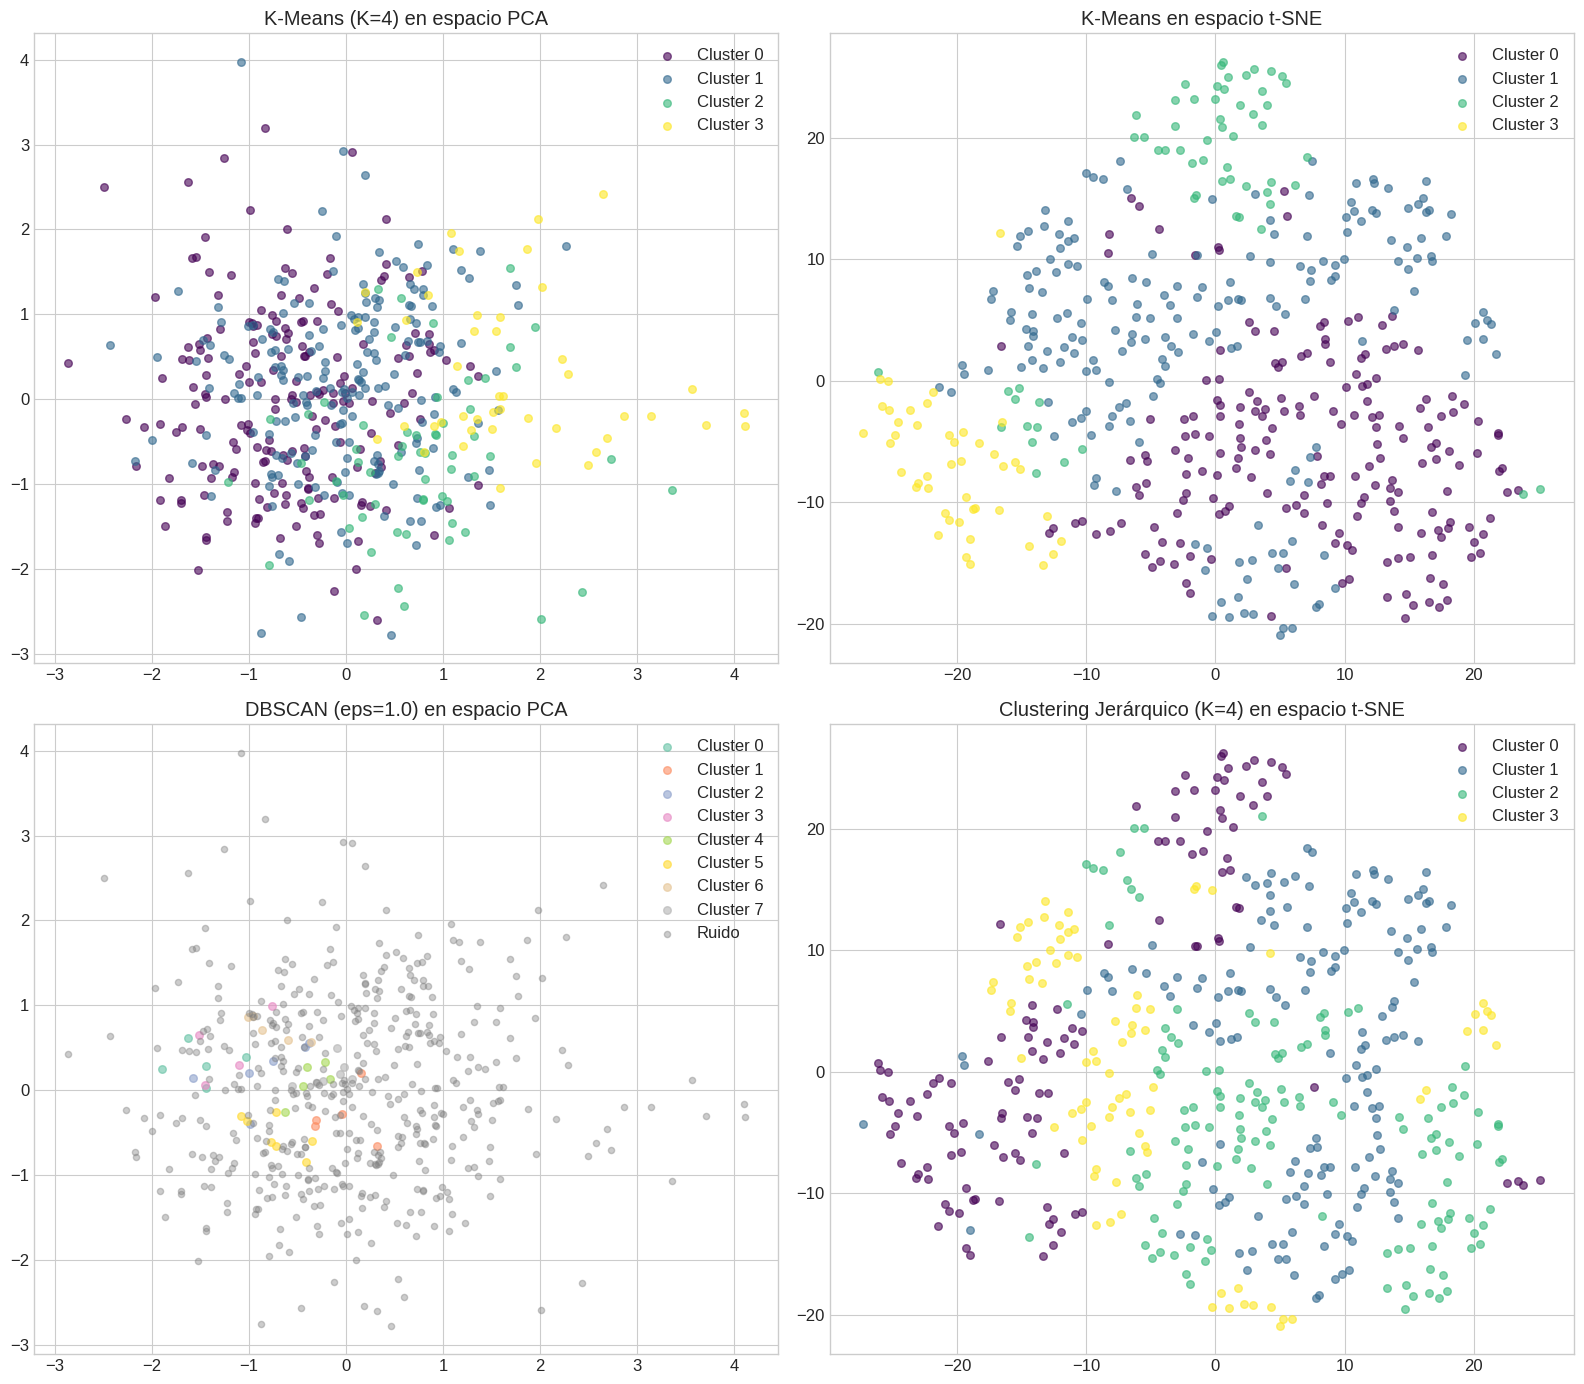

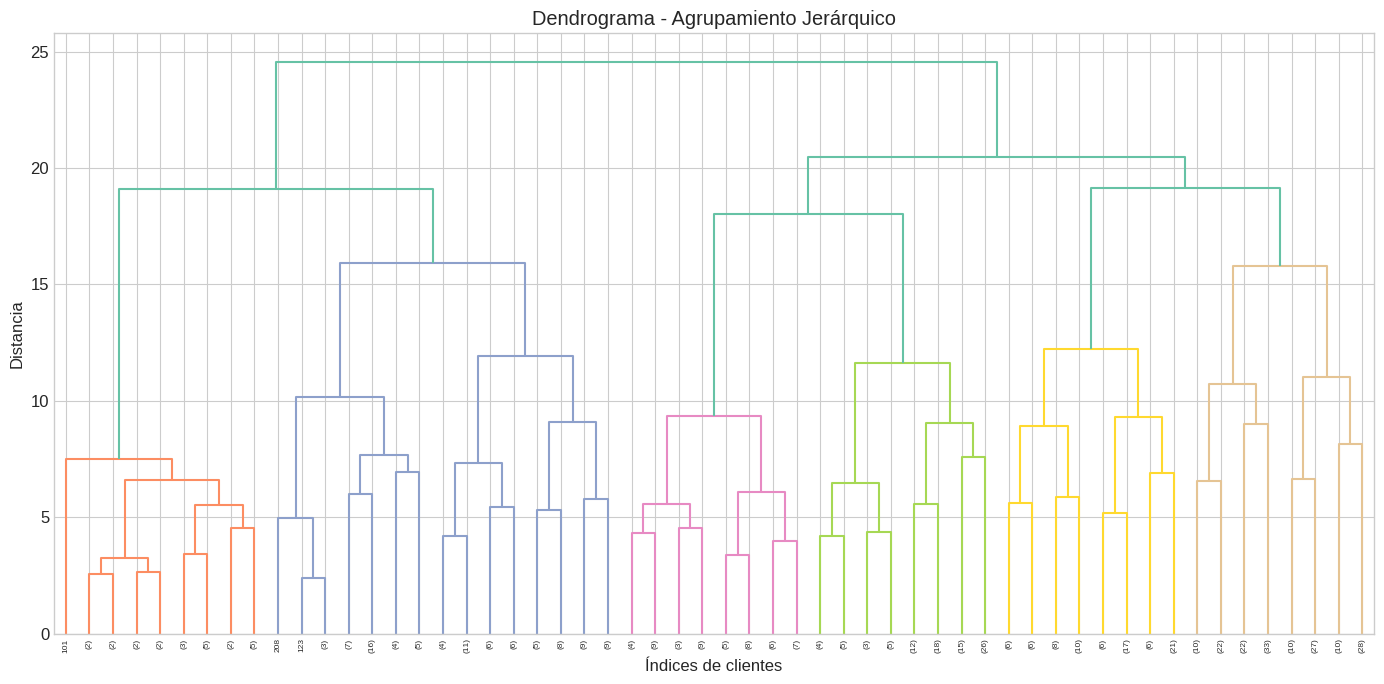


Perfiles promedio por cluster (K-Means):
              edad  ingreso_anual  gasto_total  frecuencia_compras  \
Cluster                                                              
0        56.212121   54422.297980  2806.767677           10.171717   
1        32.675127   45994.563452  3471.873096           10.177665   
2        42.000000   49491.566667  3163.900000            9.233333   
3        44.955556   42202.644444  2988.000000            9.244444   

         ticket_promedio  antiguedad_meses  dias_desde_ultima_compra  
Cluster                                                               
0              48.680101         15.357576                 19.694550  
1              53.497411         15.925381                 19.848700  
2              51.687833         70.536667                 29.491818  
3              47.927111         23.133333                 97.377136  


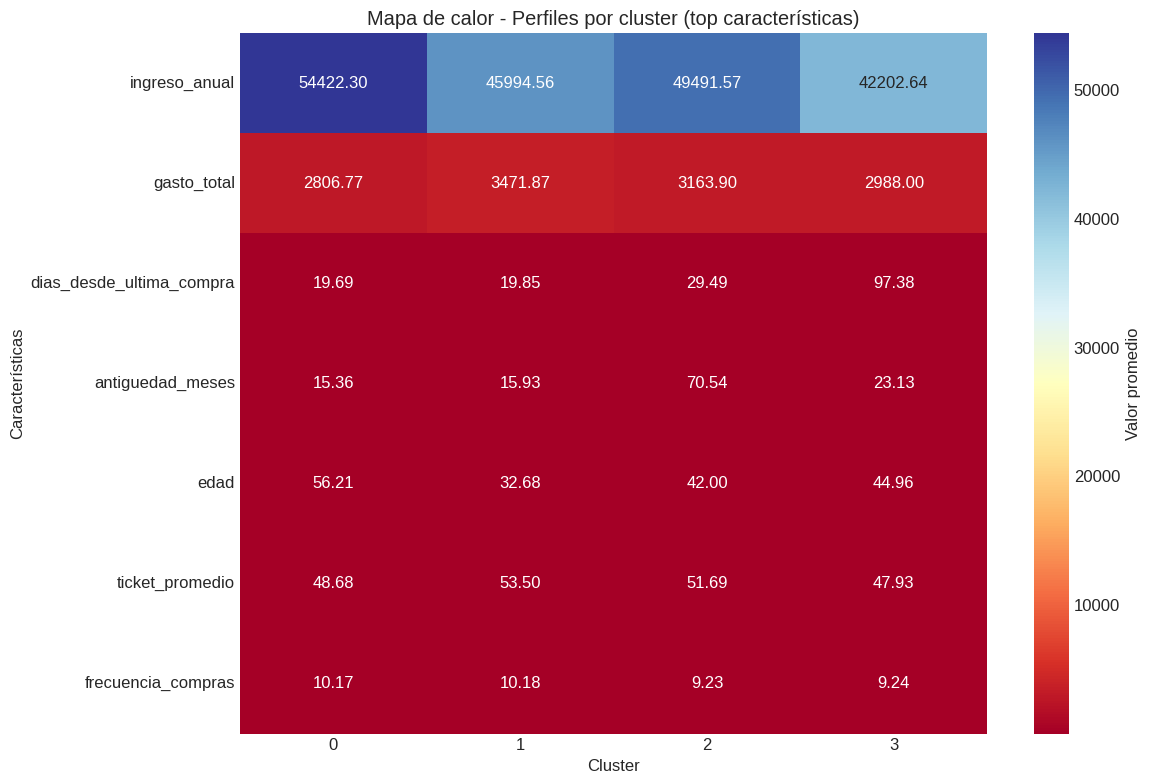


Tabla comparativa:
    Algoritmo   Silueta  N° Clusters         Ruido
0     K-Means  0.130034            4            No
1      DBSCAN  0.298764            8  456 clientes
2  Jerárquico  0.061858            4            No


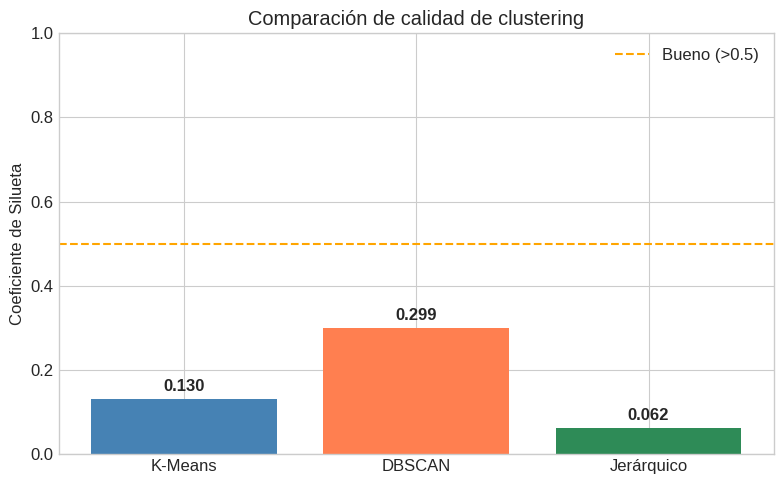


Proyecto completado exitosamente.


In [1]:
# ====================================================================
# Proyecto: Segmentador Inteligente de Clientes Minoristas
# Módulo 7: Aprendizaje de Máquina No Supervisado
# Autor: Carolina Ulloa González
# Entorno: Google Colab
# ====================================================================

# 1. Instalar y actualizar librerías (opcional, en Colab ya vienen)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

# 2. Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente")

# ====================================================================
# 3. Generar dataset sintético de clientes (500 registros, 9 variables)
# ====================================================================
np.random.seed(42)
n_clientes = 500

data = {
    'customer_id': range(1, n_clientes + 1),
    'edad': np.random.randint(18, 70, n_clientes),
    'ingreso_anual': np.random.normal(50000, 20000, n_clientes),
    'gasto_total': np.random.normal(3000, 1000, n_clientes),
    'frecuencia_compras': np.random.poisson(10, n_clientes),
    'ticket_promedio': np.random.normal(50, 20, n_clientes),
    'antiguedad_meses': np.random.exponential(24, n_clientes),
    'dias_desde_ultima_compra': np.random.exponential(30, n_clientes),
    'puntos_fidelidad': np.random.poisson(500, n_clientes)
}
df = pd.DataFrame(data)

# Redondear para mejor visualización
df['ingreso_anual'] = df['ingreso_anual'].round(0).astype(int)
df['gasto_total'] = df['gasto_total'].round(0).astype(int)
df['ticket_promedio'] = df['ticket_promedio'].round(2)
df['antiguedad_meses'] = df['antiguedad_meses'].round(1)

print(f"Dataset generado: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras 5 filas:")
print(df.head())

# ====================================================================
# 4. Preprocesamiento
# ====================================================================
# Eliminar columnas no útiles (identificadores)
df_clean = df.drop(columns=['customer_id', 'puntos_fidelidad'], errors='ignore')

# Ver valores nulos (no hay en este dataset sintético, pero por robustez)
if df_clean.isnull().sum().sum() > 0:
    df_clean = df_clean.fillna(df_clean.median())

# Detección de outliers (solo informativo)
outliers_count = 0
for col in df_clean.select_dtypes(include=[np.number]).columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    outliers_count += len(outliers)
print(f"\nTotal de outliers detectados (antes de escalado): {outliers_count}")

# Escalado de datos (importante para PCA y clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print(f"Datos escalados. Shape: {X_scaled.shape}")

# ====================================================================
# 5. Reducción dimensional: PCA
# ====================================================================
pca = PCA()
pca.fit(X_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Varianza explicada acumulada
n_comp_80 = np.argmax(cumsum >= 0.80) + 1
n_comp_90 = np.argmax(cumsum >= 0.90) + 1
n_comp_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\nComponentes necesarios para 80% varianza: {n_comp_80}")
print(f"Para 90%: {n_comp_90}, para 95%: {n_comp_95}")

# PCA a 2 componentes para visualización
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"Varianza explicada con 2 componentes: {pca_2d.explained_variance_ratio_.sum():.2%}")

# Gráfico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_title('Varianza explicada individual')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza')
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2)
axes[1].axhline(y=0.80, color='r', linestyle='--', label='80%')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90%')
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
plt.tight_layout()
plt.show()

# ====================================================================
# 6. Reducción dimensional: t-SNE
# ====================================================================
print("\nCalculando t-SNE (puede tomar unos segundos)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE completado.")

# Comparación visual PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, c='steelblue', edgecolors='white')
axes[0].set_title(f'PCA (varianza {pca_2d.explained_variance_ratio_.sum():.1%})')
axes[1].scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.6, c='coral', edgecolors='white')
axes[1].set_title('t-SNE (perplejidad=30)')
plt.tight_layout()
plt.show()

# ====================================================================
# 7. Determinación de K óptimo para K-Means (método del codo + silueta)
# ====================================================================
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Método del codo')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')
axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
axes[1].axhline(y=max(sil_scores), color='g', linestyle='--', alpha=0.7)
axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silueta')
plt.tight_layout()
plt.show()

best_k = np.argmax(sil_scores) + 2
print(f"\nMejor K según silueta: {best_k} (silueta={max(sil_scores):.4f})")

# ====================================================================
# 8. Aplicación de algoritmos de clustering
# ====================================================================
# 8.1 K-Means
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

# 8.2 DBSCAN (ajuste de eps)
best_eps = 0.5
best_dbscan_score = -1
for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    if len(set(labels)) > 1:
        score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        print(f"eps={eps}: clusters={len(set(labels))-1}, ruido={np.sum(labels==-1)}, silueta={score:.4f}")
        if score > best_dbscan_score:
            best_dbscan_score = score
            best_eps = eps
dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_scaled)
sil_dbscan = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]) if len(set(dbscan_labels)) > 1 else -1

# 8.3 Clustering Jerárquico
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)
sil_hier = silhouette_score(X_scaled, hier_labels)

print("\n--- Resultados de clustering ---")
print(f"K-Means (K={best_k}): silueta={sil_kmeans:.4f}")
print(f"DBSCAN (eps={best_eps}): silueta={sil_dbscan:.4f}, ruido={np.sum(dbscan_labels==-1)}")
print(f"Jerárquico (K={best_k}): silueta={sil_hier:.4f}")

# ====================================================================
# 9. Visualización de clusters en espacio PCA y t-SNE
# ====================================================================
colors = plt.cm.viridis(np.linspace(0, 1, best_k))
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# K-Means en PCA
for i in range(best_k):
    axes[0,0].scatter(X_pca[kmeans_labels==i, 0], X_pca[kmeans_labels==i, 1], alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0,0].set_title(f'K-Means (K={best_k}) en espacio PCA')
axes[0,0].legend()

# K-Means en t-SNE
for i in range(best_k):
    axes[0,1].scatter(X_tsne[kmeans_labels==i, 0], X_tsne[kmeans_labels==i, 1], alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[0,1].set_title(f'K-Means en espacio t-SNE')
axes[0,1].legend()

# DBSCAN en PCA
unique_labels = set(dbscan_labels)
for label in unique_labels:
    if label == -1:
        axes[1,0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1], alpha=0.4, s=20, c='gray', label='Ruido')
    else:
        axes[1,0].scatter(X_pca[dbscan_labels==label, 0], X_pca[dbscan_labels==label, 1], alpha=0.6, s=30, label=f'Cluster {label}')
axes[1,0].set_title(f'DBSCAN (eps={best_eps}) en espacio PCA')
axes[1,0].legend()

# Jerárquico en t-SNE
for i in range(best_k):
    axes[1,1].scatter(X_tsne[hier_labels==i, 0], X_tsne[hier_labels==i, 1], alpha=0.6, s=30, label=f'Cluster {i}', color=colors[i])
axes[1,1].set_title(f'Clustering Jerárquico (K={best_k}) en espacio t-SNE')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ====================================================================
# 10. Dendrograma (para clustering jerárquico)
# ====================================================================
# Usamos una muestra si el dataset es grande (500 está bien)
linkage_matrix = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma - Agrupamiento Jerárquico')
plt.xlabel('Índices de clientes')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

# ====================================================================
# 11. Perfiles de clusters (usando K-Means)
# ====================================================================
df_con_clusters = df_clean.copy()
df_con_clusters['Cluster'] = kmeans_labels
cluster_profiles = df_con_clusters.groupby('Cluster').mean()
print("\nPerfiles promedio por cluster (K-Means):")
print(cluster_profiles)

# Heatmap de las características más diferenciadoras
top_features = cluster_profiles.var().sort_values(ascending=False).head(8).index
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles[top_features].T, annot=True, fmt='.2f', cmap='RdYlBu', cbar_kws={'label': 'Valor promedio'})
plt.title('Mapa de calor - Perfiles por cluster (top características)')
plt.xlabel('Cluster')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

# ====================================================================
# 12. Comparación final de algoritmos
# ====================================================================
comparison = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'Silueta': [sil_kmeans, sil_dbscan, sil_hier],
    'N° Clusters': [best_k, len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0), best_k],
    'Ruido': ['No', f"{np.sum(dbscan_labels==-1)} clientes", 'No']
})
print("\nTabla comparativa:")
print(comparison)

plt.figure(figsize=(8,5))
bars = plt.bar(comparison['Algoritmo'], comparison['Silueta'], color=['steelblue', 'coral', 'seagreen'])
plt.axhline(y=0.5, color='orange', linestyle='--', label='Bueno (>0.5)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Comparación de calidad de clustering')
plt.ylim(0,1)
plt.legend()
for bar, score in zip(bars, comparison['Silueta']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nProyecto completado exitosamente.")